# Visualisierung der Verweildauer in der Notaufnahme mit PROC BOX

## Zusammenfassung

Eine Analyse aus dem Krankenhausbetrieb, die PROC BOXPLOT (mit dem Alias PROC BOX) verwendet, um die Verweildauer in der Notaufnahme über drei klinische Dienste hinweg zu vergleichen. Nebeneinander angeordnete schematische Boxplots zeigen auf einen Blick den Median, die Quartile, den Mittelwert und die Ausreißer mit langer Verweildauer jedes Dienstes.

Über 100 simulierte Aufnahmen hinweg steigt die mediane Verweildauer stetig von **40.0 Stunden in Medicine** über **50.4 Stunden in Surgery** auf **60.5 Stunden in Trauma**, und die Mittelwerte folgen derselben Reihenfolge (41.6, 54.6, 62.8 Stunden). Surgery weist drei hohe Ausreißer oberhalb seines oberen Whiskers auf (bis zu 84.3 Stunden) — die Boarding-Fälle, die die meisten Bettstunden verbrauchen. Das Notebook stellt den Vergleich auf drei Arten dar: als schematisches Diagramm, als Overlay mit Mittelwerttrend und als horizontales Layout.

## Datenquellen

Alle Daten werden inline vom ersten DATA-Step (`call streaminit(20260531)`) erzeugt; es werden keine externen oder Netzwerk-Eingaben verwendet.

**`ed_los`** — eine Zeile pro Notaufnahme-Aufnahme (100 Zeilen)

| Variable | Typ | Beschreibung |
|----------|------|-------------|
| `PatientID` | Num | Fortlaufender Aufnahme-Bezeichner (1-100) |
| `Department` | Char(12) | Aufnehmender Dienst: Medicine, Surgery, Trauma |
| `Severity` | Char(8) | Triage-Dringlichkeit: Routine (~55%), Urgent (~30%), Critical (~15%) |
| `LOS_Hours` | Num | Verweildauer in Stunden; ein dienst- und dringlichkeitsabhängiger Mittelwert plus normalverteiltes Rauschen, mit einem gelegentlichen Schock für lange Verweildauer (mit Label "Length of Stay (hours)") |

Die realisierte Verteilung umfasst Medicine 34 / Surgery 36 / Trauma 30 Aufnahmen sowie Routine 51 / Urgent 35 / Critical 14 nach Triage-Dringlichkeit.

# Visualisierung der Verweildauer in der Notaufnahme mit PROC BOX

Die Verweildauer (Length of Stay, LOS) ist eine der am genauesten beobachteten Betriebskennzahlen in einer Krankenhaus-Notaufnahme: Sie bestimmt die Bettenverfügbarkeit, die Personalplanung, den Patientendurchsatz und die Qualitätskennzahlen. Durchschnittswerte allein verbergen die eigentliche Geschichte — für ein Betriebsteam zählen die *Streuung* der Aufenthalte, die *Ausreißer*, die Ressourcen binden, und wie sich die Verteilungen zwischen den klinischen Diensten unterscheiden.

PROC BOX (ein Alias für PROC BOXPLOT) ist genau für diesen Vergleich gemacht. Es zeichnet nebeneinander angeordnete Box-Whisker-Diagramme, die den Median, die Quartile, den Mittelwert und die extremen Beobachtungen jeder Gruppe markieren, sodass eine Analystin oder ein Analyst die Form der LOS-Verteilung jedes Dienstes auf einen Blick ablesen kann.

In diesem Notebook:

1. Erzeugen wir einen synthetischen Datensatz von Notaufnahme-Aufnahmen, der in die Umgebung mit 100 Beobachtungen passt.
2. Erstellen wir ein schematisches Boxplot der LOS nach Abteilung mit der zugehörigen Statistiktabelle.
3. Legen wir mit `BOXCONNECT=MEAN` eine Mittelwerttrendlinie darüber, um das Gefälle zwischen den Diensten deutlich zu machen.
4. Zeichnen wir denselben Vergleich mit `HORIZONTAL` horizontal neu.

## Schritt 1 — Synthetische Notaufnahme-Daten erzeugen

Wir simulieren 100 Notaufnahme-Aufnahmen. Jede Patientin bzw. jeder Patient wird einem von drei klinischen Diensten (Medicine, Surgery, Trauma) und einer Triage-Dringlichkeit (Routine, Urgent, Critical) zugeordnet. Die Verweildauer wird aus einer dienstspezifischen Basislinie gebildet, für Patienten mit höherer Dringlichkeit nach oben verschoben und mit normalverteiltem Rauschen versehen. Ein kleiner Teil der Aufnahmen erhält einen zusätzlichen Schock für lange Verweildauer, um den schweren rechten Rand nachzubilden, den echte Notaufnahmedaten stets aufweisen (Boarding, Aufnahmen, die auf ein stationäres Bett warten). Der feste Startwert in `call streaminit` macht den Datensatz vollständig reproduzierbar.

In [1]:
OPTIONEN linesize=96;

DATEN ed_los;
   AUFRUFEN streaminit(20260531);
   LÄNGE Department $ 12 Severity $ 8;
   AUSFÜHRUNG PatientID = 1 BIS 100;
      d = rand('integer', 1, 3);
      WENN d = 1 DANN Department = 'Medizin';
      SONST WENN d = 2 DANN Department = 'Chirurgie';
      SONST Department = 'Trauma';

      u = rand('uniform');
      WENN u < 0.55 DANN s = 1;
      SONST WENN u < 0.85 DANN s = 2;
      SONST s = 3;
      WENN s = 1 DANN Severity = 'Routine';
      SONST WENN s = 2 DANN Severity = 'Dringend';
      SONST Severity = 'Kritisch';

      BASE = 24 + 10*d + 14*(s - 1);
      LOS_Hours = BASE + rand('normal', 0, 7);
      WENN rand('uniform') < 0.06 DANN
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      WENN LOS_Hours < 2 DANN LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      AUSGABE;
   ENDE;
   ENTFERNEN d u s BASE;
   BEZEICHNUNG LOS_Hours = "Verweildauer (Stunden)";
AUSFÜHREN;


NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## Schritt 2 — Nach der Gruppenvariable sortieren

PROC BOX erwartet, dass die Gruppenvariable (horizontale Achse) sortiert ist, damit die Beobachtungen jeder Gruppe zusammenhängend vorliegen. Wir sortieren vor dem Plotten nach `Department`.

In [2]:
PROZEDUR SORTIEREN DATEN=ed_los;
   NACH Department;
AUSFÜHREN;


NOTE: PROC SORT data=ed_los

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: PROC SORT statement used.


## Schritt 3 — Schematisches Boxplot

Die Kernanalyse. Die Syntax `PLOT analysis-var * group-var` fordert eine Box pro Abteilung an. `BOXSTYLE=SCHEMATIC` erzeugt ein klassisches schematisches Tukey-Diagramm: Die Whisker reichen bis zu den extremsten Beobachtungen innerhalb des 1.5-fachen Interquartilsabstands, und alle Punkte darüber hinaus werden einzeln als Ausreißer gezeichnet — ideal, um die Fälle mit langer Verweildauer zu erkennen, die die Kapazität belasten.

`NOHLABEL` unterdrückt die überflüssige Beschriftung der horizontalen Achse, da die Abteilungsnamen selbsterklärend sind. Neben dem Diagramm gibt PROC BOXPLOT eine Statistiktabelle aus, die für jede Abteilung N, Minimum, Quartile, Median, Maximum, Mittelwert und Standardabweichung angibt.

                         Verweildauer in der Notaufnahme nach Abteilung                         

                         Verweildauer in der Notaufnahme nach Abteilung

                                     The BOXPLOT Procedure

Schematic Plots for Verweildauer (Stunden)

Department            N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgie            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medizin              34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Verweildauer in der Notaufnahme nach Abteilung.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


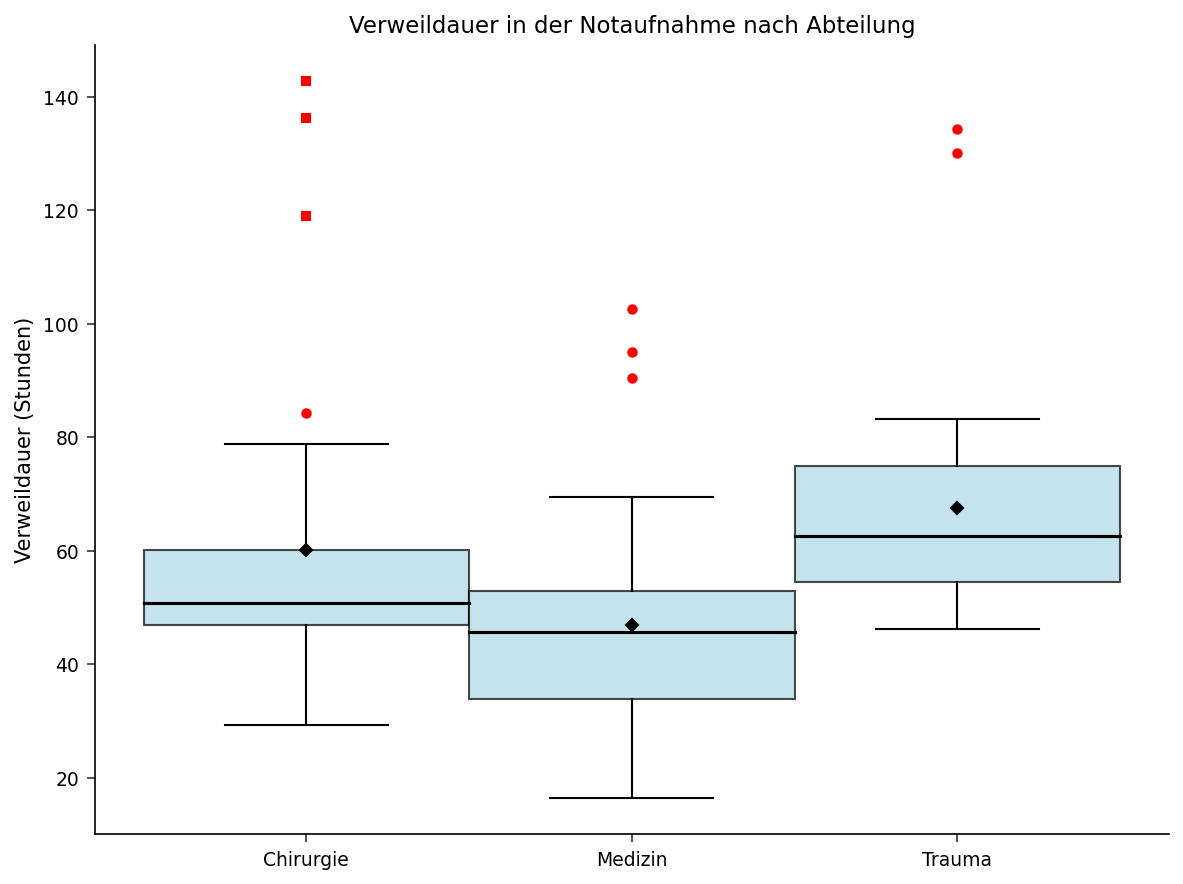

In [3]:
TITEL "Verweildauer in der Notaufnahme nach Abteilung";
PROZEDUR boxplot DATEN=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
AUSFÜHREN;

## Schritt 4 — Eine Mittelwerttrendlinie überlagern

Um das Gefälle von Dienst zu Dienst deutlich zu machen, fügen wir `BOXCONNECT=MEAN` hinzu. PROC BOXPLOT zeichnet dann eine Verbindungslinie durch den Mittelwert jeder Box (die Rautenmarkierungen) und verwandelt die drei getrennten Verteilungen in einen einzigen, gut lesbaren Trend. Da die Abteilungen in der Reihenfolge Medicine → Surgery → Trauma angeordnet sind, fasst die ansteigende Verbindungslinie die Zunahme der durchschnittlichen Verweildauer in einem Zug zusammen — ein nützlicher Hinweis für ein Betriebs-Dashboard.

                Verweildauer in der Notaufnahme nach Abteilung - Mittelwerttrend                

                Verweildauer in der Notaufnahme nach Abteilung - Mittelwerttrend

                                     The BOXPLOT Procedure

Schematic Plots for Verweildauer (Stunden)

Department            N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgie            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medizin              34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Verweildauer in der Notaufnahme nach Abteilung - Mittelwerttrend.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


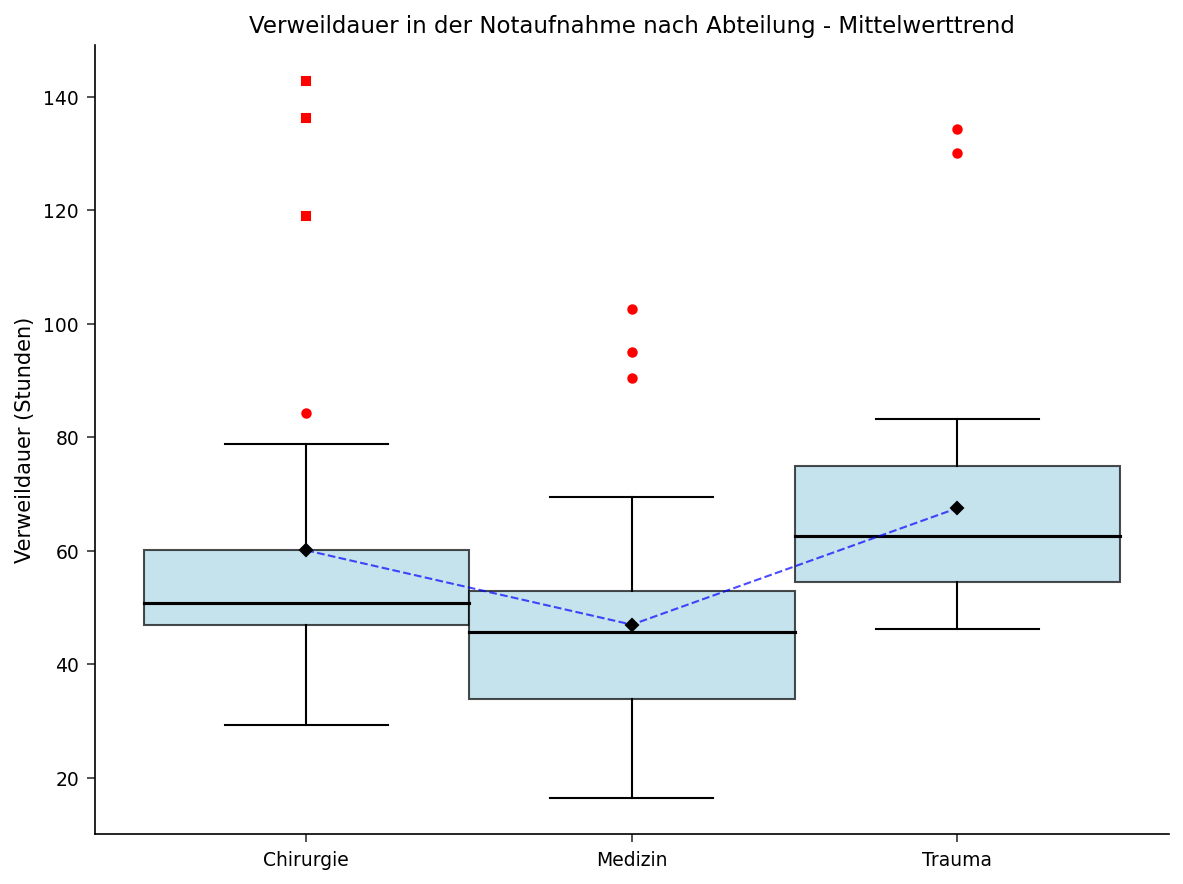

In [4]:
TITEL "Verweildauer in der Notaufnahme nach Abteilung - Mittelwerttrend";
PROZEDUR boxplot DATEN=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
AUSFÜHREN;

## Schritt 5 — Horizontales Layout

Derselbe Vergleich lässt sich auf der Seite liegend ganz natürlich lesen. Das Hinzufügen von `HORIZONTAL` vertauscht die Achsen, sodass die Boxen von links nach rechts verlaufen und die Zielgröße auf der x-Achse liegt — ein Layout, das bei langen oder zahlreichen Dienstnamen besser skaliert und das viele Betriebs-Dashboards bevorzugen. Die Statistiken sind identisch zur vertikalen Ansicht; nur die Ausrichtung ändert sich.

                  Verweildauer in der Notaufnahme nach Abteilung - Horizontal                   

                  Verweildauer in der Notaufnahme nach Abteilung - Horizontal

                                     The BOXPLOT Procedure

Schematic Plots for Verweildauer (Stunden)

Department            N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgie            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medizin              34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Verweildauer in der Notaufnahme nach Abteilung - Horizontal.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


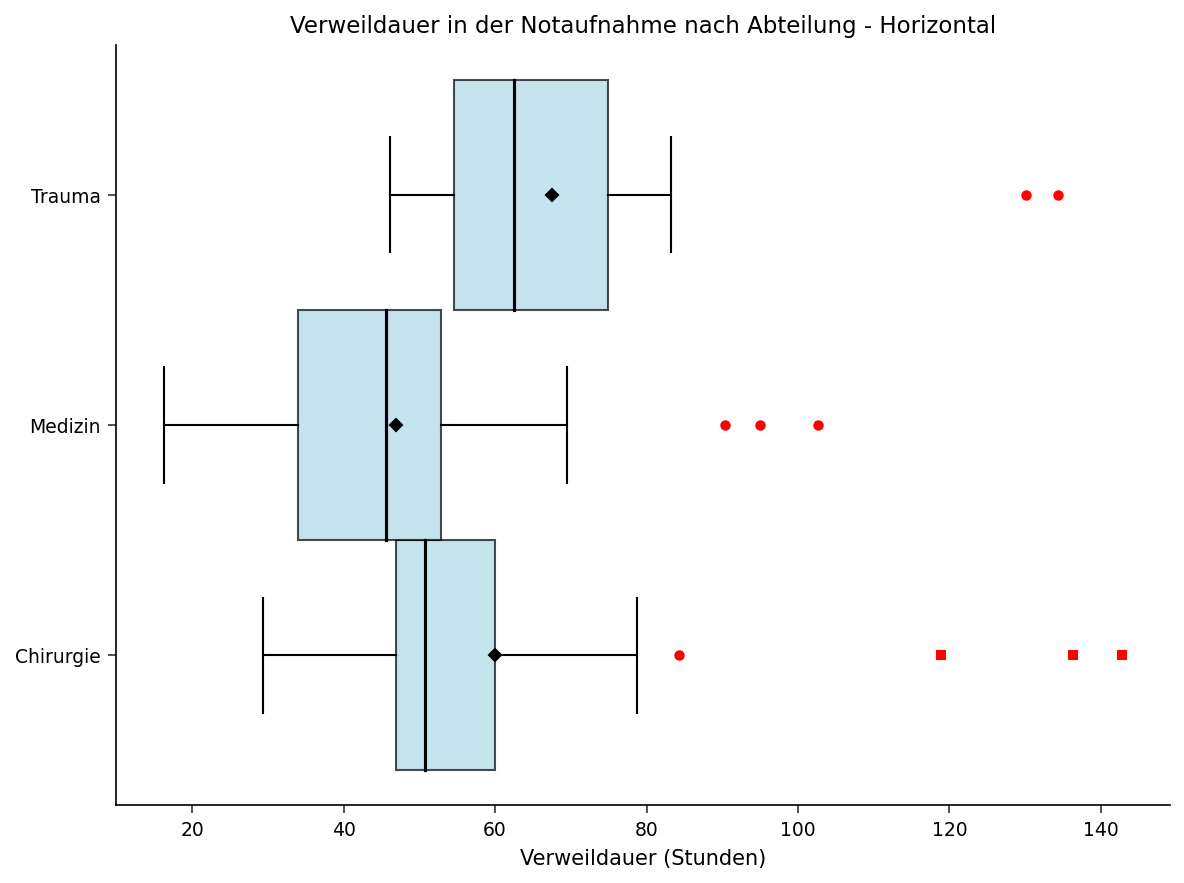

In [5]:
TITEL "Verweildauer in der Notaufnahme nach Abteilung - Horizontal";
PROZEDUR boxplot DATEN=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
AUSFÜHREN;

## Interpretation der Ergebnisse

Die Boxplots und die zugehörige Statistiktabelle übersetzen die rohen LOS-Daten in ein operativ handlungsleitendes Bild:

- **Ein klares Gefälle zwischen den Diensten.** Die mediane Verweildauer steigt über die drei Dienste hinweg monoton an: **Medicine 40.0 h → Surgery 50.4 h → Trauma 60.5 h**. Die Mittelwerte erzählen dieselbe Geschichte (41.6, 54.6, 62.8 h), und die `BOXCONNECT=MEAN`-Linie in Schritt 4 zeichnet diese Zunahme als einen einzigen ansteigenden Trend. Trauma-Patienten bleiben im Durchschnitt rund 50% länger als Medicine-Patienten.

- **Die Variabilität ist ebenso wichtig wie der Median.** Der Interquartilsabstand (die Boxhöhe) ist bei Medicine am größten (Q1 32.8 h bis Q3 51.2 h, eine Spanne von 18.3 Stunden) und bei Trauma am kleinsten (Q1 54.5 h bis Q3 68.5 h, eine Spanne von 14.0 Stunden). Medicine ist damit nicht nur der Dienst mit der kürzesten, sondern auch mit der am wenigsten vorhersagbaren Verweildauer — genau die Eigenschaft, die Prognosen für das Bettenmanagement erschwert.

- **Ausreißer markieren die Boarding-Fälle.** Die schematischen Whisker enden bei 1.5 × IQR, sodass die drei roten Punkte oberhalb des oberen Whiskers von Surgery (mit einem Höchstwert von 84.3 h) als echte Aufnahmen mit langer Verweildauer hervorstechen — genau die Boarding-Fälle, die unverhältnismäßig viele Bettstunden verbrauchen. Medicine und Trauma zeigen in dieser Stichprobe keine Punkte jenseits ihrer Whisker.

- **Die Spannweite erzählt die Geschichte der Kapazitätsplanung.** Die beobachteten Aufenthalte reichen von 16.3–69.5 h bei Medicine, 29.3–84.3 h bei Surgery und 46.1–83.2 h bei Trauma. Trauma erzeugt nie einen kurzen Aufenthalt (sein Minimum von 46.1 h übersteigt den Median von Medicine), was ein Betriebsteam vom ressourcenintensivsten Dienst erwarten würde.

Zusammen geben diese Ansichten einem Leitungsteam der Notaufnahme eine belastbare, verteilungsbewusste Grundlage für Personal- und Kapazitätsplanung — weitaus aussagekräftiger als der bloße Vergleich der durchschnittlichen LOS je Abteilung.